# Part 2 — Will this patient miss their appointment?

Plain English: the clinic wants a warning before the appointment day. We train on the supplied `CliniKit_NoShow_Dataset.csv`, then estimate the chance that a new booking will be missed.

The important rule: the final test rows stay hidden while models and the decision threshold are chosen. The repeatable implementation lives in `ml/train.py`; this notebook is the walkthrough.

In [1]:
from pathlib import Path
import sys

# This works whether Jupyter starts in the repo root or ml/notebooks.
current = Path.cwd().resolve()
project_root = next(p for p in (current, *current.parents) if (p / "ml" / "train.py").exists())
sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display
from ml.train import load_frame, prepare, explore, train

df = load_frame()
print(f"Rows: {len(df):,}; columns: {len(df.columns)}")
df.head()

Rows: 3,000; columns: 12


,appointment_id,age,gender,appointment_type,days_before_appointment,previous_appointments,previous_no_shows,weekday,appointment_time,reminder_sent,new_patient,no_show
0,1,59,Female,Follow-up,12,7,1,Monday,16:00-18:00,0,0,0
1,2,92,Male,Follow-up,4,4,2,Monday,08:00-10:00,1,0,1
2,3,59,Female,Follow-up,17,0,0,Wednesday,10:00-12:00,0,1,0
3,4,66,Female,New Consultation,7,0,0,Tuesday,12:00-14:00,1,1,0
4,5,65,Male,Routine Check,17,2,0,Thursday,14:00-16:00,0,0,0


## 1. Basic exploration

First question: how common are no-shows, and is the file clean? Only 15.9% are no-shows. That means an “always attends” guess gets about 84% accuracy while catching zero missed appointments, so accuracy cannot be our main score.

In [2]:
summary = explore(df)
print(f"No-shows: {summary['no_shows']} ({summary['no_show_rate']:.1%})")
print(f"Missing cells: {summary['missing_cells']}")
print(f"Duplicate rows / IDs: {summary['duplicate_rows']} / {summary['duplicate_ids']}")

display(df.describe(include="all").T)
display(df["no_show"].value_counts().rename(index={0: "attended", 1: "no-show"}))

No-shows: 478 (15.9%)
Missing cells: 0
Duplicate rows / IDs: 0 / 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appointment_id,3000.0,NaN,NaN,NaN,1500.5,866.169729,1.0,750.75,1500.5,2250.25,3000.0
age,3000.0,NaN,NaN,NaN,41.360667,17.593685,1.0,30.0,41.0,53.0,92.0
gender,3000,2,Female,1634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_type,3000,5,Follow-up,1118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_before_appointment,3000.0,NaN,NaN,NaN,9.909333,7.9636,0.0,4.0,8.0,14.0,59.0
previous_appointments,3000.0,NaN,NaN,NaN,4.673333,5.324604,0.0,1.0,3.0,7.0,30.0
previous_no_shows,3000.0,NaN,NaN,NaN,0.592667,1.013125,0.0,0.0,0.0,1.0,6.0
weekday,3000,6,Tuesday,553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_time,3000,6,16:00-18:00,672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reminder_sent,3000.0,NaN,NaN,NaN,0.787,0.409496,0.0,1.0,1.0,1.0,1.0


no_show
attended    2522
no-show      478
Name: count, dtype: int64

In [3]:
print("No-show rate by reminder")
display(
    df.groupby("reminder_sent")["no_show"].agg(["size", "mean"])
      .rename(index={0: "no reminder", 1: "reminder sent"})
)

print("No-show rate by appointment type")
display(
    df.groupby("appointment_type")["no_show"].agg(["size", "mean"])
      .sort_values("mean", ascending=False)
)

# Association is not causation: this does not prove that reminders caused attendance.

No-show rate by reminder


,size,mean
reminder_sent,,
no reminder,639,0.222222
reminder sent,2361,0.142313


No-show rate by appointment type


,size,mean
appointment_type,,
New Consultation,715,0.201399
Urgent Visit,280,0.167857
Follow-up,1118,0.154741
Routine Check,539,0.142857
Procedure,348,0.106322


## 2. Preparation, model selection, and evaluation

Preparation:
- Drop `appointment_id`: it identifies a row but says nothing useful about risk.
- One-hot encode text categories such as weekday and appointment type.
- Standardise numeric columns for logistic regression.
- Add `past_no_show_rate` from the two history counts.

Selection:
- Hold out 20% as the final test set.
- Compare a dummy baseline, logistic regression, histogram gradient boosting, and random forest with five-fold cross-validation on the other 80%.
- Choose by ROC-AUC, then choose the flagging threshold from training-only predictions.

Because no-shows are uncommon, the main metrics are ROC-AUC, PR-AUC, and precision/recall/F1 for `no_show`—not ordinary accuracy alone.

In [4]:
X, y = prepare(df)
print("Model columns:", list(X.columns))
print("appointment_id used?", "appointment_id" in X.columns)

metrics = train()
pd.DataFrame(metrics["model_comparison"])

Model columns: ['gender', 'appointment_type', 'weekday', 'appointment_time', 'age', 'days_before_appointment', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'new_patient', 'past_no_show_rate']
appointment_id used? False


Model comparison (5-fold CV on training rows)
  logistic_regression      ROC-AUC 0.694  PR-AUC 0.368
  random_forest            ROC-AUC 0.672  PR-AUC 0.333
  hist_gradient_boosting   ROC-AUC 0.648  PR-AUC 0.294
  dummy_baseline           ROC-AUC 0.500  PR-AUC 0.159

Selected: logistic_regression
Threshold: 0.263
Test ROC-AUC 0.695 | PR-AUC 0.372 | precision 0.384 | recall 0.344 | F1 0.363

Saved model: /Users/ahmadzeid/Developer/ClinikitApp/ml/models/no_show_pipeline.joblib
Saved metrics: /Users/ahmadzeid/Developer/ClinikitApp/ml/models/metrics.json
Saved report: /Users/ahmadzeid/Developer/ClinikitApp/ml/RESULTS.md


,model,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_balanced_accuracy_mean
0,logistic_regression,0.693804,0.033452,0.367716,0.545711
1,random_forest,0.671518,0.022113,0.332500,0.658291
2,hist_gradient_boosting,0.647607,0.018980,0.294282,0.624211
3,dummy_baseline,0.500000,0.000000,0.159167,0.500000


## 3. Results and example predictions

The winning logistic model is moderate, not production-ready. The saved charts show its held-out ranking quality, confusion matrix, and which raw inputs it relied on. `ml/predict.py` then scores three fictional appointment examples.

The model is advisory only. In a real clinic it could suggest an extra reminder; it must not cancel, deny, or overbook care automatically.

{'selected_model': 'logistic_regression', 'test_roc_auc': 0.695, 'test_pr_auc': 0.372, 'no_show_precision': 0.384, 'no_show_recall': 0.344, 'threshold': 0.263}


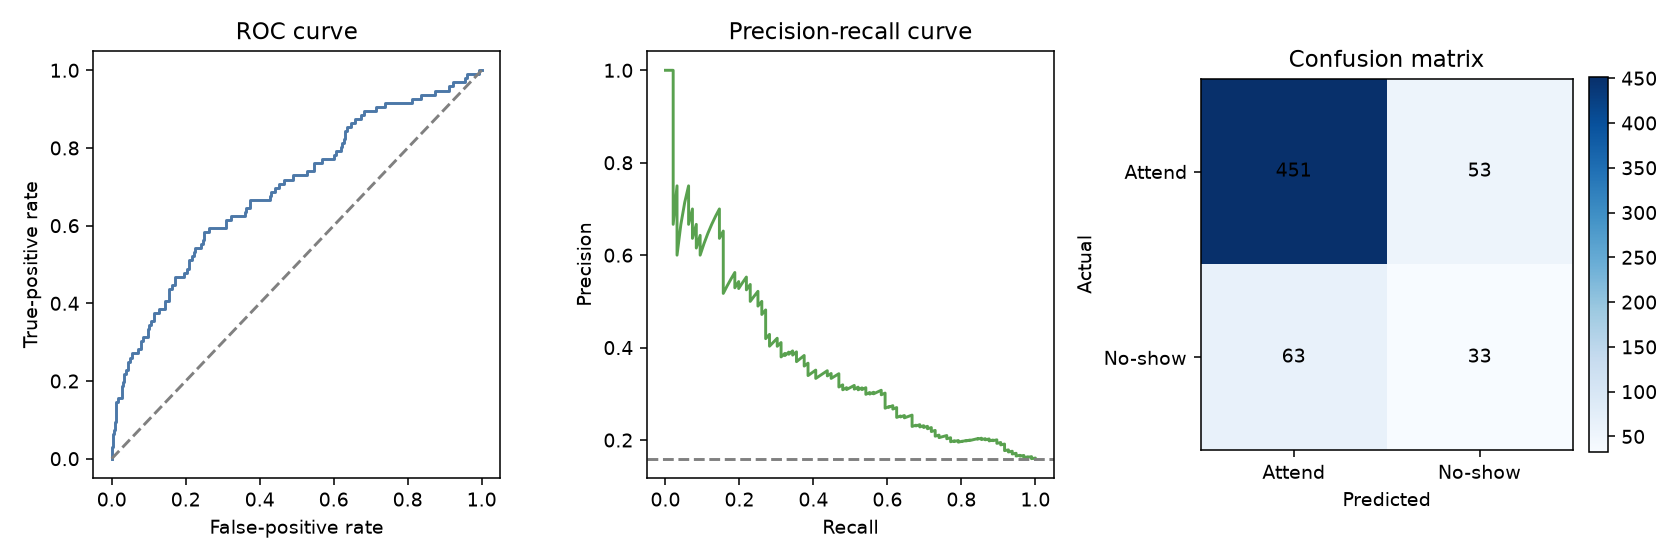

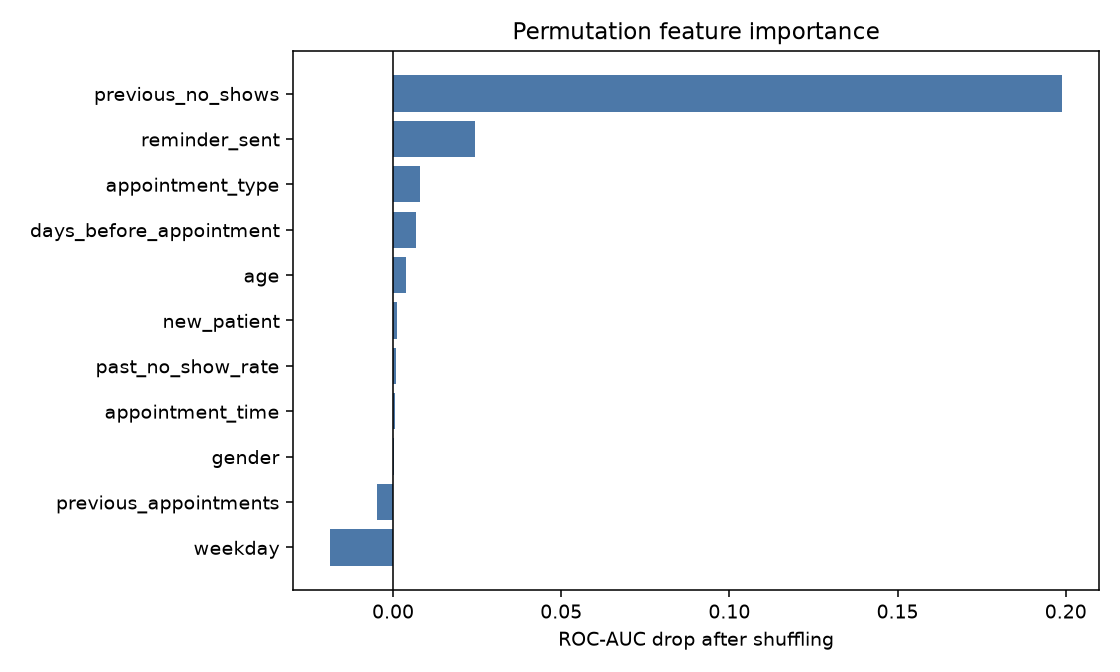

Example predictions (estimated probability of a no-show)

  [ok  ]  6.0%  Returning patient, reminder sent, no earlier misses
  [FLAG] 38.1%  New consultation, booked well ahead, no reminder
  [FLAG] 84.6%  Returning patient with several earlier misses, no reminder

Flagging threshold: 0.263
These are risk estimates for workflow support, not automatic decisions.


In [5]:
print({
    "selected_model": metrics["selected_model"],
    "test_roc_auc": round(metrics["test_roc_auc"], 3),
    "test_pr_auc": round(metrics["test_pr_auc"], 3),
    "no_show_precision": round(metrics["test_precision_no_show"], 3),
    "no_show_recall": round(metrics["test_recall_no_show"], 3),
    "threshold": round(metrics["threshold"], 3),
})

display(Image(filename=str(project_root / "ml" / "figures" / "model_evaluation.png")))
display(Image(filename=str(project_root / "ml" / "figures" / "feature_importance.png")))

from ml.predict import main as show_example_predictions
show_example_predictions()